In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [5]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1) Hypothesis Testing: ANOVA test (3+ groups) (Region vs. Insurance Charges)

Null Hypothesis: There is no statistical difference in the mean charges between at least one pair of regions.
Alternative Hypothesis: There is a statistical difference in the mean charges between at least one pair of regions.

In [11]:
nw = df[df["region"] == "northwest"]["charges"]
ne = df[df["region"] == "northeast"]["charges"]
sw = df[df["region"] == "southwest"]["charges"]
se = df[df["region"] == "southeast"]["charges"]

f_statistic, p_value = stats.f_oneway(nw, ne, sw, se)
print(f'f_statistic: {f_statistic}, p_value: {p_value}')

f_statistic: 2.9696266935891193, p_value: 0.0308933560705201


A P-Value of roughly 0.03 demonstrates that the null hypothesis can be rejected.

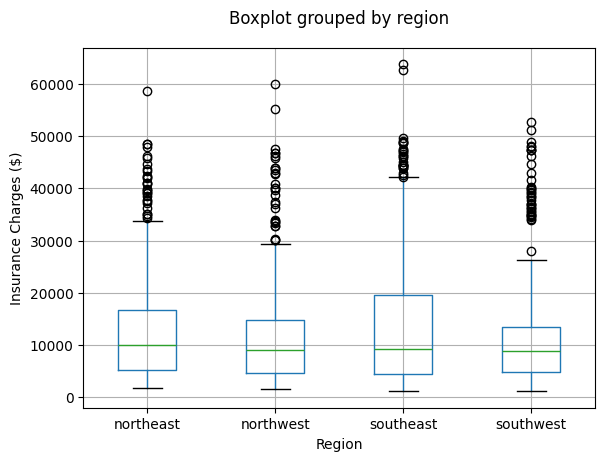

In [33]:
bp = df.boxplot(column="charges", by="region")
bp.get_figure().gca().set_title("")

plt.xlabel("Region")
plt.ylabel("Insurance Charges ($)")

plt.show()

Through the p-value it is evident that there is a significant difference between insurance charges across regions, specifically involving the Southeast region, however, the boxplot shows high overlap in distributions and the areas that the boxes cover. This suggests that while there are differences they are relatively small for most pairs and the Southeast region is an outlier in terms of exhibiting higher variability and higher charges. Thus, this proves that region is not a main driver of insurance charges.

2. Chi-Square Test (Smoker Status vs. BMI)

Null Hypothesis: There is no statistical difference between BMI and the smoking status of an individual.
Alternative Hypothesis: There is a statistical difference between BMI and the smoking status of an individual.

In [27]:
# Contingency Table between smoker and bmi fields
df['bmi_groups'] = pd.cut(df['bmi'], bins=[15, 20, 25, 30, 35, 40, 45, 50, 55], labels=["15-20", "20-25", "25-30", "30-35", "35-40", "40-45", "45-50", "50-55"])
contingency_table = pd.crosstab(df['bmi_groups'], df['smoker'])
contingency_table

smoker,no,yes
bmi_groups,,
15-20,32,9
20-25,160,46
25-30,311,75
30-35,316,73
35-40,175,50
40-45,55,16
45-50,13,4
50-55,2,1


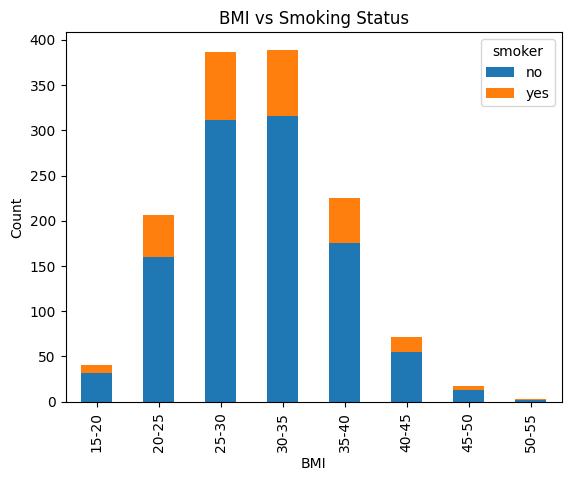

In [28]:
contingency_table.plot(kind='bar', stacked=True)
plt.title("BMI vs Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

In [29]:
_, p, _, _ = stats.chi2_contingency(contingency_table)
print(f'P-Value: {p}')

P-Value: 0.9304137095386342


In this case the chi-squared test outputted a p-value of roughly 0.93 which is greater than 0.05, which demonstrates that there is no significant association between the BMI and smoking status of an individual. Thus, the null hypothesis cannot be rejected.

3. Mann-Whitney U Test (Smoker Status vs. Charges)

Null Hypothesis: There is no statistical difference between the smoking status and the insurance charges of an individual.
Alternative Hypothesis: There is a statistical difference between the smoking status and the insurance charges of an individual.

In [30]:
smoker = df[df['smoker'] == 'yes']['charges']
non_smoker = df[df['smoker'] == 'no']['charges']

_, p = stats.mannwhitneyu(non_smoker, smoker)
print(f'P-Value: {p}')

P-Value: 5.270233444503571e-130


In this case the Mann-Whitney U Test outputted a p-value of 5.27x10^-130 which is significantly smaller than 0.05 which indicates that the null hypothesis can certainly be rejected and there is a clear statistical difference between smoking status and their insurance charges.

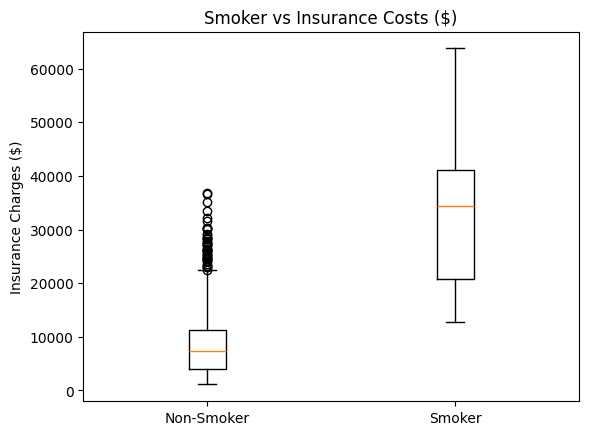

In [39]:
plt.boxplot([non_smoker, smoker], tick_labels=['Non-Smoker', 'Smoker'])
plt.title('Smoker vs Insurance Costs ($)')
plt.ylabel('Insurance Charges ($)')
plt.show()

The boxplot shows that insurance charges significantly vary between non-smokers and smokers since the mean for non-smokers lies below 10k and the mean insurance cost for smokers lies roughly at 35k. There also exists a large spread of smokers compared to non-smokers which is indicated by their quartiles (edges) being farther apart than the mean. Therefore, it is fair to say that the binary value of whether or not an individual is a smoker is a strong relationship to use for future analysis and predictions.